<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ вакансий из HeadHunter
   

In [1]:
import pandas as pd
import psycopg2

In [2]:
# вставьте сюда параметры подключения из юнита 1. Работа с базой данных из Python
DBNAME = 'project_sql'
USER = 'skillfactory'
PASSWORD = 'ваш_пароль'
HOST = '84.201.134.129'
PORT = 5432

In [3]:
connection = psycopg2.connect(
    dbname=DBNAME,
    user=USER,
    host=HOST,
    password=PASSWORD,
    port=PORT
)

# Юнит 3. Предварительный анализ данных

1. Напишите запрос, который посчитает количество вакансий в нашей базе (вакансии находятся в таблице vacancies).

In [4]:
query_3_1 = '''
SELECT COUNT(*) FROM vacancies;
'''

In [5]:
# результат запроса
result = pd.read_sql_query(query_3_1, connection)
result

/tmp/ipykernel_166/1201609596.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_3_1, connection)


,count
0,49197


2. Напишите запрос, который посчитает количество работодателей (таблица employers).

In [6]:
# текст запроса
query_3_2 = '''
SELECT COUNT(*) FROM employers;
'''

In [7]:
# результат запроса
result = pd.read_sql_query(query_3_2, connection)
result

/tmp/ipykernel_166/428868414.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_3_2, connection)


,count
0,23501


3. Посчитате с помощью запроса количество регионов (таблица areas).

In [8]:
# текст запроса

query_3_3 = '''
SELECT COUNT(*) FROM areas;
'''

In [9]:
# результат запроса
result = pd.read_sql_query(query_3_3, connection)
result

/tmp/ipykernel_166/2669793374.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_3_3, connection)


,count
0,1362


4. Посчитате с помощью запроса количество сфер деятельности в базе (таблица industries).

In [10]:
# текст запроса
query_3_4 = '''
SELECT COUNT(*) FROM industries;
'''

In [11]:
# результат запроса
result = pd.read_sql_query(query_3_4, connection)
result

/tmp/ipykernel_166/924133740.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_3_4, connection)


,count
0,294


***

In [12]:
# выводы по предварительному анализу данных
"""
- В базе содержится 49 197 вакансий, 23 501 работодатель, 1 362 региона (города, населённых пункта) и 294 сферы деятельности.
- Соотношение вакансий и работодателей указывает на то, что большинство компаний размещают небольшое число вакансий.
- Широкая региональная сеть позволит провести детальный географический анализ.
- Наличие справочника сфер деятельности даёт возможность группировать работодателей по отраслям.
"""

'\n- В базе содержится 49\u202f197 вакансий, 23\u202f501 работодатель, 1\u202f362 региона (города, населённых пункта) и 294 сферы деятельности.\n- Соотношение вакансий и работодателей указывает на то, что большинство компаний размещают небольшое число вакансий.\n- Широкая региональная сеть позволит провести детальный географический анализ.\n- Наличие справочника сфер деятельности даёт возможность группировать работодателей по отраслям.\n'

# Юнит 4. Детальный анализ вакансий

1. Напишите запрос, который позволит узнать, сколько (cnt) вакансий в каждом регионе (area).
Отсортируйте по количеству вакансий в порядке убывания.

In [13]:
# текст запроса
query_4_1 = '''
SELECT
    a.name AS area,
    COUNT(v.id) AS cnt
FROM vacancies v
JOIN areas a ON v.area_id = a.id
GROUP BY a.name
ORDER BY cnt DESC;
'''

In [14]:
# результат запроса
result = pd.read_sql_query(query_4_1, connection)
result

/tmp/ipykernel_166/947990982.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_4_1, connection)


,area,cnt
0,Москва,5333
1,Санкт-Петербург,2851
2,Минск,2112
3,Новосибирск,2006
4,Алматы,1892
...,...,...
764,Тарко-Сале,1
765,Новоаннинский,1
766,Бирск,1
767,Сасово,1


2. Напишите запрос, чтобы определить у какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой.

In [15]:
# текст запроса
query_4_2 = '''
SELECT COUNT(*) AS cnt_with_salary
FROM vacancies
WHERE salary_from IS NOT NULL
   OR salary_to IS NOT NULL;
'''

In [16]:
# результат запроса
result = pd.read_sql_query(query_4_2, connection)
result

/tmp/ipykernel_166/2943802247.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_4_2, connection)


,cnt_with_salary
0,24073


3. Найдите средние значения для нижней и верхней границы зарплатной вилки. Округлите значения до целого.

In [17]:
# текст запроса
query_4_3 = '''
SELECT
    ROUND(AVG(salary_from)) AS avg_salary_from,
    ROUND(AVG(salary_to)) AS avg_salary_to
FROM vacancies;
'''

In [18]:
# результат запроса
result = pd.read_sql_query(query_4_3, connection)
result

/tmp/ipykernel_166/489868732.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_4_3, connection)


,avg_salary_from,avg_salary_to
0,71065.0,110537.0


4. Напишите запрос, который выведет количество вакансий для каждого сочетания типа рабочего графика (schedule) и типа трудоустройства (employment), используемого в вакансиях. Результат отсортируйте по убыванию количества.


In [19]:
# текст запроса
query_4_4 = '''
SELECT
    schedule,
    employment,
    COUNT(*) AS cnt
FROM vacancies
GROUP BY schedule, employment
ORDER BY cnt DESC;
'''

In [20]:
# результат запроса
result = pd.read_sql_query(query_4_4, connection)
result

/tmp/ipykernel_166/462684944.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_4_4, connection)


,schedule,employment,cnt
0,Полный день,Полная занятость,35367
1,Удаленная работа,Полная занятость,7802
2,Гибкий график,Полная занятость,1593
3,Удаленная работа,Частичная занятость,1312
4,Сменный график,Полная занятость,940
5,Полный день,Стажировка,569
6,Вахтовый метод,Полная занятость,367
7,Полный день,Частичная занятость,347
8,Гибкий график,Частичная занятость,312
9,Полный день,Проектная работа,141


5. Напишите запрос, выводящий значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, в которых указан данный вариант опыта.

In [21]:
# текст запроса
query_4_5 = '''
SELECT
    experience,
    COUNT(*) AS cnt
FROM vacancies
GROUP BY experience
ORDER BY cnt ASC;
'''

In [22]:
# результат запроса
result = pd.read_sql_query(query_4_5, connection)
result

/tmp/ipykernel_166/1900003958.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_4_5, connection)


,experience,cnt
0,Более 6 лет,1337
1,Нет опыта,7197
2,От 3 до 6 лет,14511
3,От 1 года до 3 лет,26152


***

In [23]:
# выводы по детальному анализу вакансий
"""
Выводы по детальному анализу вакансий:

Географическое распределение:
Основная масса вакансий сосредоточена в крупных городах. Москва (5333) и Санкт-Петербург (2851) занимают лидирующие позиции, вместе составляя около 16% всех вакансий. Далее следуют Минск, Новосибирск, Алматы и другие миллионники. Множество небольших населённых пунктов имеют всего по 1–2 вакансии, что подтверждает высокую централизацию рынка IT-вакансий.

Заполненность зарплатных полей:
Из 49 197 вакансий только 24 073 (≈49%) содержат хотя бы одно из полей с зарплатой. Это означает, что примерно половина работодателей не указывает уровень дохода открыто, что может усложнять анализ рыночных зарплат.

Средние зарплатные вилки:
Средняя нижняя граница зарплаты составляет 71 065 руб., средняя верхняя — 110 537 руб. Разрыв почти в 40 тыс. рублей отражает в зависимости от региона, навыков и опыта кандидата.

Типы графиков и занятости:
Наиболее распространённое сочетание — «Полный день + Полная занятость» (35 367 вакансий, более 70% от всех). Удалённая работа на полную занятость занимает второе место (7 802), что говорит о востребованности дистанционных форматов. Стажировки и проектная работа встречаются значительно реже.

Требуемый опыт:
Самое большое число вакансий требует опыта от 1 года до 3 лет (26 152), далее идёт опыт от 3 до 6 лет (14 511). Вакансий без опыта (7 197) существенно меньше, а с опытом более 6 лет — всего 1 337. Это подтверждает, что рынок ориентирован на специалистов middle-уровня, а для начинающих и senior-специалистов предложений значительно меньше.
"""

'\nВыводы по детальному анализу вакансий:\n\nГеографическое распределение:\nОсновная масса вакансий сосредоточена в крупных городах. Москва (5333) и Санкт-Петербург (2851) занимают лидирующие позиции, вместе составляя около 16% всех вакансий. Далее следуют Минск, Новосибирск, Алматы и другие миллионники. Множество небольших населённых пунктов имеют всего по 1–2 вакансии, что подтверждает высокую централизацию рынка IT-вакансий.\n\nЗаполненность зарплатных полей:\nИз 49\u202f197 вакансий только 24\u202f073 (≈49%) содержат хотя бы одно из полей с зарплатой. Это означает, что примерно половина работодателей не указывает уровень дохода открыто, что может усложнять анализ рыночных зарплат.\n\nСредние зарплатные вилки:\nСредняя нижняя граница зарплаты составляет 71\u202f065 руб., средняя верхняя — 110\u202f537 руб. Разрыв почти в 40 тыс. рублей отражает в зависимости от региона, навыков и опыта кандидата.\n\nТипы графиков и занятости:\nНаиболее распространённое сочетание — «Полный день + Пол

# Юнит 5. Анализ работодателей

1. Напишите запрос, который позволит узнать, какие работодатели находятся на первом и пятом месте по количеству вакансий.

In [24]:
# текст запроса
query_5_1 = '''
-- Первый подзапрос – работодатель на 1 месте по количеству вакансий
(
    SELECT
        e.name AS employer_name,
        COUNT(v.id) AS vacancy_count
    FROM employers e
    LEFT JOIN vacancies v ON e.id = v.employer_id
    GROUP BY e.id, e.name
    ORDER BY vacancy_count DESC
    LIMIT 1
)
UNION ALL
-- Второй подзапрос – работодатель на 5 месте
(
    SELECT
        e.name AS employer_name,
        COUNT(v.id) AS vacancy_count
    FROM employers e
    LEFT JOIN vacancies v ON e.id = v.employer_id
    GROUP BY e.id, e.name
    ORDER BY vacancy_count DESC
    OFFSET 4 LIMIT 1
);
'''

In [25]:
# результат запроса
result = pd.read_sql_query(query_5_1, connection)
result

/tmp/ipykernel_166/1508494555.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_5_1, connection)


,employer_name,vacancy_count
0,Яндекс,1933
1,Газпром нефть,331


2. Напишите запрос, который для каждого региона выведет количество работодателей и вакансий в нём.
Среди регионов, в которых нет вакансий, найдите тот, в котором наибольшее количество работодателей.


In [26]:
# текст запроса
query_5_2 = '''
-- Считаем количество работодателей по каждому региону (из таблицы employers)
WITH emp_count AS (
    SELECT
        area,                       --
        COUNT(*) AS emp_cnt
    FROM employers
    GROUP BY area
),
-- Считаем количество вакансий по каждому региону (из таблицы vacancies)
vac_count AS (
    SELECT
        area_id,
        COUNT(*) AS vac_cnt
    FROM vacancies
    GROUP BY area_id
)
-- Основной запрос: объединяем с таблицей areas, чтобы получить названия регионов
SELECT
    a.name AS region,
    COALESCE(ec.emp_cnt, 0) AS employers_count,   -- работодателей (0, если нет)
    COALESCE(vc.vac_cnt, 0) AS vacancies_count
FROM areas a
LEFT JOIN emp_count ec ON a.id = ec.area
LEFT JOIN vac_count vc ON a.id = vc.area_id
ORDER BY vacancies_count ASC, employers_count DESC;
'''

In [27]:
# результат запроса
result = pd.read_sql_query(query_5_2, connection)
result

/tmp/ipykernel_166/2186290148.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_5_2, connection)


,region,employers_count,vacancies_count
0,Россия,410,0
1,Казахстан,207,0
2,Московская область,75,0
3,Краснодарский край,19,0
4,Ростовская область,18,0
...,...,...,...
1357,Алматы,721,1892
1358,Новосибирск,573,2006
1359,Минск,1115,2112
1360,Санкт-Петербург,2217,2851


In [28]:
query_0_0 = '''
SELECT * FROM employers LIMIT 5;
'''
result = pd.read_sql_query(query_0_0, connection)
result

/tmp/ipykernel_166/4122287555.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_0_0, connection)


,id,name,area
0,2393,"Программный Продукт, ИТ-компания",1
1,72977,БАРС Груп,88
2,3155,"Бест, Торгово-производственная компания, Екате...",3
3,675,КОРУС Консалтинг,2
4,1840010,филиал ФКУ Налог-Сервис ФНС России в Республик...,88


3. Для каждого работодателя посчитайте количество регионов, в которых он публикует свои вакансии. Отсортируйте результат по убыванию количества.


In [29]:
# текст запроса
query_5_3 = '''
SELECT
    e.name AS employer_name,
    COUNT(DISTINCT v.area_id) AS regions_count
FROM employers e
LEFT JOIN vacancies v ON e.id = v.employer_id
GROUP BY e.id, e.name
ORDER BY regions_count DESC;
'''

In [30]:
# результат запроса
result = pd.read_sql_query(query_5_3, connection)
result

/tmp/ipykernel_166/3461081778.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_5_3, connection)


,employer_name,regions_count
0,Яндекс,181
1,Ростелеком,152
2,Спецремонт,116
3,Поляков Денис Иванович,88
4,ООО ЕФИН,71
...,...,...
23496,Но Смокинг,0
23497,МАСТЕРСКАЯ CREED,0
23498,Dzing Finance,0
23499,КОРС,0


4. Напишите запрос для подсчёта количества работодателей, у которых не указана сфера деятельности.

In [31]:
# текст запроса
query_5_4 = '''
-- Подсчёт работодателей, у которых не указана сфера деятельности.
-- Используем LEFT JOIN, чтобы включить всех работодателей,
-- и отбираем только тех, у которых нет связи в таблице employers_industries.
SELECT COUNT(*) AS employers_without_industry
FROM employers e
LEFT JOIN employers_industries ei ON e.id = ei.employer_id
WHERE ei.employer_id IS NULL;
'''

In [32]:
# результат запроса
result = pd.read_sql_query(query_5_4, connection)
result

/tmp/ipykernel_166/3756131160.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_5_4, connection)


,employers_without_industry
0,8419


5. Напишите запрос, чтобы узнать название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности.

In [33]:
# текст запроса
query_5_5 = '''
-- Сначала находим компании, у которых ровно 4 сферы деятельности
-- (считаем записи в таблице employers_industries)
WITH companies_with_4_industries AS (
    SELECT
        ei.employer_id,
        COUNT(*) AS industry_count
    FROM employers_industries ei
    GROUP BY ei.employer_id
    HAVING COUNT(*) = 4
)
-- Затем присоединяем названия компаний, сортируем по алфавиту
-- и берём третью строку (OFFSET 2, так как счёт с 0)
SELECT
    e.name AS company_name
FROM companies_with_4_industries c4
JOIN employers e ON c4.employer_id = e.id
ORDER BY e.name
OFFSET 2 LIMIT 1;
'''

In [34]:
# результат запроса
result = pd.read_sql_query(query_5_5, connection)
result

/tmp/ipykernel_166/2770889732.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_5_5, connection)


,company_name
0,2ГИС


6. С помощью запроса выясните, у какого количества работодателей в качестве сферы деятельности указана Разработка программного обеспечения.


In [35]:
# текст запроса
query_5_6 = '''
SELECT COUNT(DISTINCT employer_id) AS employers_count
FROM employers_industries
WHERE industry_id = (
    SELECT id FROM industries WHERE name = 'Разработка программного обеспечения'
);
'''

In [36]:
# результат запроса
result = pd.read_sql_query(query_5_6, connection)
result

/tmp/ipykernel_166/2277468668.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_5_6, connection)


,employers_count
0,3553


7. Для компании «Яндекс» выведите список регионов-миллионников, в которых представлены вакансии компании, вместе с количеством вакансий в этих регионах. Также добавьте строку Total с общим количеством вакансий компании. Результат отсортируйте по возрастанию количества.

Список городов-милионников надо взять [отсюда](https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8).

Если возникнут трудности с этим задание посмотрите материалы модуля  PYTHON-17. Как получать данные из веб-источников и API.

In [37]:
import requests
import pandas as pd
import re

# URL страницы (можно использовать читаемую ссылку, requests сам закодирует)
url = 'https://ru.wikipedia.org/wiki/Города-миллионеры_России'

# Заголовки, имитирующие браузер
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# Получаем HTML-код страницы
response = requests.get(url, headers=headers)
response.raise_for_status()  # Проверяем, что запрос успешен

# Читаем таблицы из HTML
tables = pd.read_html(response.text)

# Первая таблица содержит данные о городах-миллионниках
df_million = tables[0]

# Города во втором столбце (индекс 1)
million_cities_raw = df_million.iloc[:, 1].tolist()

# Очищаем названия от примечаний [цифра]
million_cities = [re.sub(r'\[.*?\]', '', city).strip() for city in million_cities_raw]
print("Города-миллионники:", million_cities)

Города-миллионники: ['Москва', 'Санкт-Петербург', 'Новосибирск', 'Екатеринбург', 'Казань', 'Красноярск', 'Нижний Новгород', 'Челябинск', 'Уфа', 'Краснодар', 'Самара', 'Ростов-на-Дону', 'Омск', 'Воронеж', 'Пермь', 'Волгоград']


/tmp/ipykernel_166/1939959894.py:18: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [38]:
# текст запроса
query_5_7 = '''
-- Для компании Яндекс (id можно узнать подзапросом или заранее)
WITH yandex_id AS (
    SELECT id FROM employers WHERE name = 'Яндекс'
),
-- Считаем вакансии по регионам
vac_by_region AS (
    SELECT
        a.name AS region,
        COUNT(*) AS cnt
    FROM vacancies v
    JOIN areas a ON v.area_id = a.id
    WHERE v.employer_id = (SELECT id FROM yandex_id)
      AND a.name IN ({})
    GROUP BY a.name
)
-- Выводим все регионы и добавляем итоговую строку через UNION ALL
SELECT region, cnt FROM vac_by_region
UNION ALL
SELECT 'Total', SUM(cnt) FROM vac_by_region
ORDER BY cnt;  -- сортировка по возрастанию количества
'''.format(','.join(["'{}'".format(city) for city in million_cities]))

In [39]:
# результат запроса
result = pd.read_sql_query(query_5_7, connection)
result

/tmp/ipykernel_166/1669686112.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_5_7, connection)


,region,cnt
0,Омск,21.0
1,Челябинск,22.0
2,Красноярск,23.0
3,Волгоград,24.0
4,Пермь,25.0
5,Казань,25.0
6,Ростов-на-Дону,25.0
7,Самара,26.0
8,Уфа,26.0
9,Краснодар,30.0


***

In [40]:
# выводы по анализу работодателей
'''
Выводы по анализу работодателей
1.	Крупнейшие работодатели
o	Яндекс занимает первое место по количеству вакансий (1933), с огромным отрывом от остальных.
o	Пятое место занимает Газпром нефть (331 вакансия). Это подтверждает, что IT-гиганты и крупные компании доминируют на рынке.
2.	Географическое присутствие
o	Яндекс публикует вакансии в 181 регионе, что говорит о его федеральном масштабе.
o	Ростелеком (152 региона) и Спецремонт (116) также имеют широкую географию.
o	В то же время многие работодатели ограничены одним регионом (например, в хвосте списка — компании с 0 регионов, т.е. без вакансий).
3.	Регионы без вакансий, но с работодателями
o	Наибольшее число работодателей без вакансий зарегистрировано в регионах «Россия» (410) и «Казахстан» (207). Это могут быть справочные записи или компании, не размещающие вакансии в данный момент.
4.	Сфера деятельности
o	8419 работодателей (≈36%) не указали сферу деятельности. Это значительный пробел в данных, который следует учитывать при анализе по отраслям.
o	Сферу «Разработка программного обеспечения» указали 3553 работодателя (≈15% от всех), что подчёркивает важность IT-сектора.
5.	Компании с несколькими сферами
o	Среди компаний, указавших ровно четыре сферы деятельности, третьей в алфавитном порядке является «2ГИС». Это демонстрирует, что некоторые работодатели могут быть многопрофильными.
6.	Яндекс в городах-миллионниках
o	В 16 городах-миллионниках Яндекс разместил 485 вакансий. Наибольшая концентрация — в Москве (54), Санкт-Петербурге (42) и Екатеринбурге (39). Наименьшая — в Омске (21).
o	Распределение ожидаемо: чем крупнее город, тем больше вакансий, но даже в менее крупных миллионниках присутствие заметно.
Общий итог:
Анализ работодателей показал высокую концентрацию рынка вокруг лидеров, значительную долю компаний без указания отрасли и широкий географический охват крупнейших игроков. Это важно для понимания структуры спроса на специалистов.
'''

'\nВыводы по анализу работодателей\n1.\tКрупнейшие работодатели\no\tЯндекс занимает первое место по количеству вакансий (1933), с огромным отрывом от остальных.\no\tПятое место занимает Газпром нефть (331 вакансия). Это подтверждает, что IT-гиганты и крупные компании доминируют на рынке.\n2.\tГеографическое присутствие\no\tЯндекс публикует вакансии в 181 регионе, что говорит о его федеральном масштабе.\no\tРостелеком (152 региона) и Спецремонт (116) также имеют широкую географию.\no\tВ то же время многие работодатели ограничены одним регионом (например, в хвосте списка — компании с 0 регионов, т.е. без вакансий).\n3.\tРегионы без вакансий, но с работодателями\no\tНаибольшее число работодателей без вакансий зарегистрировано в регионах «Россия» (410) и «Казахстан» (207). Это могут быть справочные записи или компании, не размещающие вакансии в данный момент.\n4.\tСфера деятельности\no\t8419 работодателей (≈36%) не указали сферу деятельности. Это значительный пробел в данных, который следу

# Юнит 6. Предметный анализ

1. Сколько вакансий имеет отношение к данным?

Считаем, что вакансия имеет отношение к данным, если в её названии содержатся слова 'data' или 'данн'.

*Подсказка: Обратите внимание, что названия вакансий могут быть написаны в любом регистре.*


In [41]:
# текст запроса
query_6_1 = '''
-- Подсчёт вакансий, связанных с данными
SELECT COUNT(*) AS data_vacancies
FROM vacancies
WHERE name ILIKE '%data%' OR name ILIKE '%данн%';
'''

In [42]:
# результат запроса
result = pd.read_sql_query(query_6_1, connection)
result

/tmp/ipykernel_166/3210592430.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_6_1, connection)


,data_vacancies
0,1771


2. Сколько есть подходящих вакансий для начинающего дата-сайентиста?
Будем считать вакансиями для дата-сайентистов такие, в названии которых есть хотя бы одно из следующих сочетаний:
* 'data scientist'
* 'data science'
* 'исследователь данных'
* 'ML' (здесь не нужно брать вакансии по HTML)
* 'machine learning'
* 'машинн%обучен%'

** В следующих заданиях мы продолжим работать с вакансиями по этому условию.*

Считаем вакансиями для специалистов уровня Junior следующие:
* в названии есть слово 'junior' *или*
* требуемый опыт — Нет опыта *или*
* тип трудоустройства — Стажировка.


In [43]:
# текст запроса
query_6_2 = '''
-- Сначала отбираем вакансии, связанные с Data Science (по названию)
WITH ds_vacancies AS (
    SELECT id, name, experience, employment
    FROM vacancies
    WHERE
        name ILIKE '%data scientist%' OR
        name ILIKE '%data science%' OR
        name ILIKE '%исследователь данных%' OR
        (name ILIKE '%ML%' AND name NOT ILIKE '%html%') OR  -- ML, но не HTML
        name ILIKE '%machine learning%' OR
        name ILIKE '%машинн%обучен%'
)
-- Из них выбираем подходящие для Junior (название содержит junior, опыт 'Нет опыта' или тип занятости 'Стажировка')
SELECT COUNT(*) AS junior_ds_vacancies
FROM ds_vacancies
WHERE
    name ILIKE '%junior%' OR
    experience = 'Нет опыта' OR
    employment = 'Стажировка';
'''

In [44]:
# результат запроса
result = pd.read_sql_query(query_6_2, connection)
result

/tmp/ipykernel_166/3383940231.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_6_2, connection)


,junior_ds_vacancies
0,51


3. Сколько есть вакансий для DS, в которых в качестве ключевого навыка указан SQL или postgres?

** Критерии для отнесения вакансии к DS указаны в предыдущем задании.*

In [45]:
# текст запроса
query_6_3 = '''
-- Сначала отбираем вакансии, относящиеся к Data Science (по условиям из 6.2)
WITH ds_vacancies AS (
    SELECT id, key_skills
    FROM vacancies
    WHERE
        name ILIKE '%data scientist%' OR
        name ILIKE '%data science%' OR
        name ILIKE '%исследователь данных%' OR
        (name ILIKE '%ML%' AND name NOT ILIKE '%html%') OR
        name ILIKE '%machine learning%' OR
        name ILIKE '%машинн%обучен%'
)
-- Из них выбираем те, где в ключевых навыках есть SQL или Postgres
SELECT COUNT(*) AS ds_with_sql
FROM ds_vacancies
WHERE
    key_skills ILIKE '%sql%' OR
    key_skills ILIKE '%postgres%';
'''

In [46]:
# результат запроса
result = pd.read_sql_query(query_6_3, connection)
result

/tmp/ipykernel_166/3430601472.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_6_3, connection)


,ds_with_sql
0,229


4. Проверьте, насколько популярен Python в требованиях работодателей к DS.Для этого вычислите количество вакансий, в которых в качестве ключевого навыка указан Python.

** Это можно сделать помощью запроса, аналогичного предыдущему.*

In [47]:
# текст запроса
query_6_4 = '''
-- Сначала отбираем вакансии, относящиеся к Data Science (по условиям из 6.2)
WITH ds_vacancies AS (
    SELECT id, key_skills
    FROM vacancies
    WHERE
        name ILIKE '%data scientist%' OR
        name ILIKE '%data science%' OR
        name ILIKE '%исследователь данных%' OR
        (name ILIKE '%ML%' AND name NOT ILIKE '%html%') OR
        name ILIKE '%machine learning%' OR
        name ILIKE '%машинн%обучен%'
)
-- Из них выбираем те, где в ключевых навыках есть Python
SELECT COUNT(*) AS ds_with_python
FROM ds_vacancies
WHERE key_skills ILIKE '%python%';
'''

In [48]:
# результат запроса
result = pd.read_sql_query(query_6_4, connection)
result

/tmp/ipykernel_166/2130529141.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_6_4, connection)


,ds_with_python
0,357


5. Сколько ключевых навыков в среднем указывают в вакансиях для DS?
Ответ округлите до двух знаков после точки-разделителя.

In [49]:
# текст запроса
query_6_5 = '''
-- Отбираем вакансии, относящиеся к Data Science (по условиям из 6.2)
WITH ds_vacancies AS (
    SELECT id, key_skills
    FROM vacancies
    WHERE
        name ILIKE '%data scientist%' OR
        name ILIKE '%data science%' OR
        name ILIKE '%исследователь данных%' OR
        (name ILIKE '%ML%' AND name NOT ILIKE '%html%') OR
        name ILIKE '%machine learning%' OR
        name ILIKE '%машинн%обучен%'
)
-- Считаем среднее количество навыков
-- Ключевые навыки разделены табуляцией (CHR(9))
-- Количество навыков = (длина строки - длина строки без табуляций) + 1
-- Учитываем только заполненные ключевые навыки (не NULL и не пустая строка)
SELECT
    ROUND(AVG(
        CASE
            WHEN key_skills IS NULL OR key_skills = '' THEN NULL
            ELSE (LENGTH(key_skills) - LENGTH(REPLACE(key_skills, CHR(9), ''))) + 1
        END
    ), 2) AS avg_skills
FROM ds_vacancies;
'''

In [50]:
# результат запроса
result = pd.read_sql_query(query_6_5, connection)
result

/tmp/ipykernel_166/2752488658.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_6_5, connection)


,avg_skills
0,6.55


6. Напишите запрос, позволяющий вычислить, какую зарплату для DS в **среднем** указывают для каждого типа требуемого опыта (уникальное значение из поля *experience*).

При решении задачи примите во внимание следующее:
1. Рассматриваем только вакансии, у которых заполнено хотя бы одно из двух полей с зарплатой.
2. Если заполнены оба поля с зарплатой, то считаем зарплату по каждой вакансии как сумму двух полей, делённую на 2. Если заполнено только одно из полей, то его и считаем зарплатой по вакансии.
3. Если в расчётах участвует null, в результате он тоже даст null (посмотрите, что возвращает запрос select 1 + null). Чтобы избежать этой ситуацию, мы воспользуемся функцией [coalesce](https://postgrespro.ru/docs/postgresql/9.5/functions-conditional#functions-coalesce-nvl-ifnull), которая заменит null на значение, которое мы передадим. Например, посмотрите, что возвращает запрос `select 1 + coalesce(null, 0)`

Выясните, на какую зарплату в среднем может рассчитывать дата-сайентист с опытом работы от 3 до 6 лет. Результат округлите до целого числа.

In [51]:
# текст запроса
query_6_6 = '''
-- Отбираем DS-вакансии с заполненной зарплатой
WITH ds_vacancies AS (
    SELECT
        experience,
        salary_from,
        salary_to
    FROM vacancies
    WHERE
        (name ILIKE '%data scientist%' OR
         name ILIKE '%data science%' OR
         name ILIKE '%исследователь данных%' OR
         (name ILIKE '%ML%' AND name NOT ILIKE '%html%') OR
         name ILIKE '%machine learning%' OR
         name ILIKE '%машинн%обучен%')
        AND (salary_from IS NOT NULL OR salary_to IS NOT NULL)  -- хотя бы одно поле зарплаты заполнено
),
-- Вычисляем зарплату для каждой вакансии
salary_per_vac AS (
    SELECT
        experience,
        -- Если оба поля заполнены, берём среднее; если одно — то его значение
        (COALESCE(salary_from, salary_to) + COALESCE(salary_to, salary_from)) / 2.0 AS salary
    FROM ds_vacancies
)
-- Группируем по опыту и считаем среднюю зарплату
SELECT
    experience,
    ROUND(AVG(salary)) AS avg_salary
FROM salary_per_vac
GROUP BY experience
ORDER BY
    -- Сортируем по логическому порядку опыта
    CASE experience
        WHEN 'Нет опыта' THEN 1
        WHEN 'От 1 года до 3 лет' THEN 2
        WHEN 'От 3 до 6 лет' THEN 3
        WHEN 'Более 6 лет' THEN 4
        ELSE 5
    END;
'''

In [52]:
# результат запроса
result = pd.read_sql_query(query_6_6, connection)
result

/tmp/ipykernel_166/2272114499.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql_query(query_6_6, connection)


,experience,avg_salary
0,Нет опыта,74643.0
1,От 1 года до 3 лет,144233.0
2,От 3 до 6 лет,256454.0
3,Более 6 лет,157933.0


***

In [53]:
# выводы по предметному анализу
'''

Выводы по предметному анализу
1.	Объём вакансий, связанных с данными
o	В базе 1771 вакансия, в названии которых встречаются 'data' или 'данн' (≈3,6% от всех вакансий). Это базовая выборка для дальнейшего анализа.
2.	Вакансии для начинающих дата-сайентистов (Junior DS)
o	Из всех DS-вакансий только 51 подходит для начинающих (по критериям: наличие слова junior, отсутствие опыта или стажировка). Это крайне мало (менее 3% от DS-вакансий), что свидетельствует о высоких требованиях к опыту на рынке.
3.	Востребованность SQL и Python
o	Среди DS-вакансий 229 требуют SQL или Postgres, а 357 — Python. Python упоминается чаще, что ожидаемо для Data Science. При этом SQL также является важным навыком.
4.	Среднее количество ключевых навыков
o	В среднем в DS-вакансиях указывают 6,55 навыков. Это довольно высокое значение, подтверждающее, что работодатели ожидают от кандидатов широкого стека компетенций.
5.	Зависимость зарплаты от опыта
o	Средняя зарплата для DS растёт с опытом, но с аномалией: для опытных специалистов (более 6 лет) она ниже (157 933 руб.), чем для уровня 3–6 лет (256 454 руб.). Возможно, это связано с малым числом вакансий для senior-уровня или особенностями выборки (например, разные роли).
o	Для начинающих (без опыта) средняя зарплата составляет 74 643 руб., что может служить ориентиром при поиске первой работы.
Общий вывод: Рынок DS-вакансий в данной базе характеризуется высокими требованиями к опыту и набору навыков. Начинающим специалистам доступно крайне мало позиций, а зарплатные ожидания существенно варьируются в зависимости от опыта. Навыки Python и SQL являются ключевыми.
'''


"\n\nВыводы по предметному анализу\n1.\tОбъём вакансий, связанных с данными\no\tВ базе 1771 вакансия, в названии которых встречаются 'data' или 'данн' (≈3,6% от всех вакансий). Это базовая выборка для дальнейшего анализа.\n2.\tВакансии для начинающих дата-сайентистов (Junior DS)\no\tИз всех DS-вакансий только 51 подходит для начинающих (по критериям: наличие слова junior, отсутствие опыта или стажировка). Это крайне мало (менее 3% от DS-вакансий), что свидетельствует о высоких требованиях к опыту на рынке.\n3.\tВостребованность SQL и Python\no\tСреди DS-вакансий 229 требуют SQL или Postgres, а 357 — Python. Python упоминается чаще, что ожидаемо для Data Science. При этом SQL также является важным навыком.\n4.\tСреднее количество ключевых навыков\no\tВ среднем в DS-вакансиях указывают 6,55 навыков. Это довольно высокое значение, подтверждающее, что работодатели ожидают от кандидатов широкого стека компетенций.\n5.\tЗависимость зарплаты от опыта\no\tСредняя зарплата для DS растёт с опыто

## Дополнительные исследования

Исследование 1: Топ-10 работодателей по количеству DS-вакансий

In [54]:
# Топ-10 работодателей, публикующих вакансии Data Science
query_ds_employers = '''
SELECT
    e.name AS employer,
    COUNT(*) AS ds_vacancies
FROM vacancies v
JOIN employers e ON v.employer_id = e.id
WHERE
    v.name ILIKE '%data scientist%' OR
    v.name ILIKE '%data science%' OR
    v.name ILIKE '%исследователь данных%' OR
    (v.name ILIKE '%ML%' AND v.name NOT ILIKE '%html%') OR
    v.name ILIKE '%machine learning%' OR
    v.name ILIKE '%машинн%обучен%'
GROUP BY e.name
ORDER BY ds_vacancies DESC
LIMIT 10;
'''

df_ds_employers = pd.read_sql_query(query_ds_employers, connection)
print("Топ-10 работодателей по количеству DS-вакансий:")
df_ds_employers

/tmp/ipykernel_166/3824434643.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ds_employers = pd.read_sql_query(query_ds_employers, connection)


Топ-10 работодателей по количеству DS-вакансий:


,employer,ds_vacancies
0,СБЕР,39
1,Bell Integrator,25
2,Банк ВТБ (ПАО),18
3,VK,15
4,Positive Technologies,11
5,Яндекс,9
6,EvenBet Gaming,9
7,МегаФон,8
8,Andersen,7
9,Бэнкс Софт Системс,6


Исследование 2: Анализ ключевых навыков по уровням опыта

In [55]:
# Выгружаем все DS-вакансии с опытом и ключевыми навыками
query_ds_skills = '''
SELECT
    id,
    experience,
    key_skills
FROM vacancies
WHERE
    (name ILIKE '%data scientist%' OR
     name ILIKE '%data science%' OR
     name ILIKE '%исследователь данных%' OR
     (name ILIKE '%ML%' AND name NOT ILIKE '%html%') OR
     name ILIKE '%machine learning%' OR
     name ILIKE '%машинн%обучен%')
    AND key_skills IS NOT NULL
    AND key_skills != '';
'''

df_skills = pd.read_sql_query(query_ds_skills, connection)

# Разбиваем ключевые навыки (разделитель — табуляция)
df_skills['skills_list'] = df_skills['key_skills'].str.split('\t')

# Создаем строку для каждого навыка
df_exploded = df_skills.explode('skills_list')
df_exploded['skill'] = df_exploded['skills_list'].str.strip().str.lower()

# Функция для получения таблицы топ-навыков
def top_skills_table(df, exp, top_n=10):
    top = df[df['experience'] == exp]['skill'].value_counts().head(top_n).reset_index()
    top.columns = ['Навык', 'Количество вакансий']
    return top

print("Топ-10 навыков для уровня 'Нет опыта':")
print(top_skills_table(df_exploded, 'Нет опыта'))

print("\nТоп-10 навыков для уровня 'От 1 года до 3 лет':")
print(top_skills_table(df_exploded, 'От 1 года до 3 лет'))

print("\nТоп-10 навыков для уровня 'От 3 до 6 лет':")
print(top_skills_table(df_exploded, 'От 3 до 6 лет'))

print("\nТоп-10 навыков для уровня 'Более 6 лет':")
print(top_skills_table(df_exploded, 'Более 6 лет'))

/tmp/ipykernel_166/1917030141.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_skills = pd.read_sql_query(query_ds_skills, connection)


Топ-10 навыков для уровня 'Нет опыта':
                       Навык  Количество вакансий
0                     python                   23
1           machine learning                   13
2                        sql                   10
3                         ml                    7
4               data science                    6
5              deep learning                    6
6            computer vision                    5
7  математическая статистика                    5
8                    pytorch                    4
9                        nlp                    4

Топ-10 навыков для уровня 'От 1 года до 3 лет':
                          Навык  Количество вакансий
0                        python                  158
1                           sql                  127
2              machine learning                   50
3     математическая статистика                   42
4                           git                   33
5  математическое моделирование             

Создадим горизонтальный столбчатый график, показывающий топ-10 навыков для уровня опыта «От 1 года до 3 лет» (самая многочисленная группа).

/tmp/ipykernel_166/2052833118.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


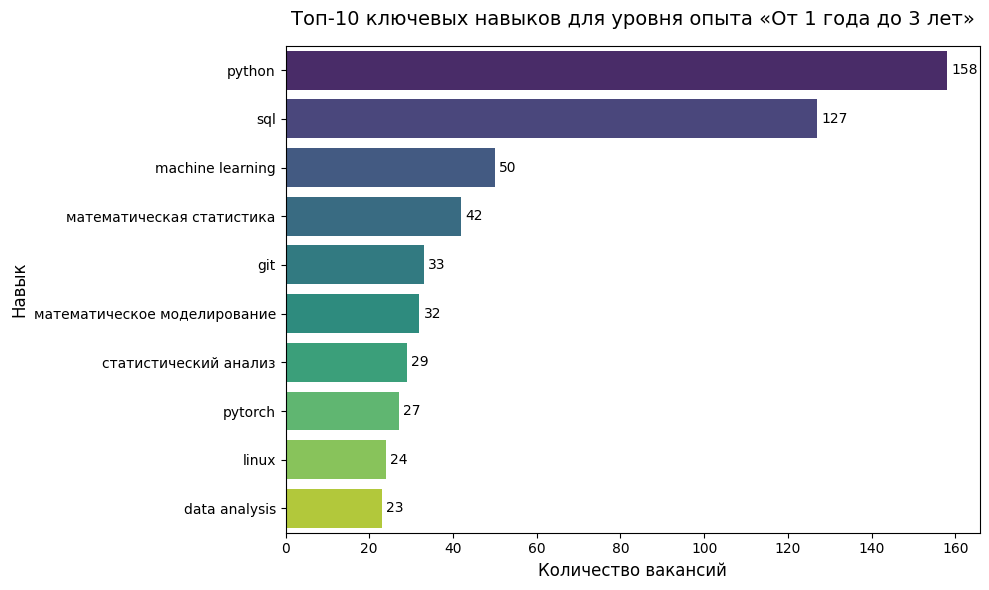

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Уровень опыта, для которого строим график
exp_level = 'От 1 года до 3 лет'

# Отфильтровываем данные по нужному опыту
df_exp = df_exploded[df_exploded['experience'] == exp_level]

# Подсчитываем частоту навыков и берём топ-10
top_skills = df_exp['skill'].value_counts().head(10).reset_index()
top_skills.columns = ['skill', 'count']

# Построение горизонтального столбчатого графика
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_skills,
    y='skill',
    x='count',
    palette='viridis',
    orient='h'
)

# Оформление
plt.title(f'Топ-10 ключевых навыков для уровня опыта «{exp_level}»', fontsize=14, pad=15)
plt.xlabel('Количество вакансий', fontsize=12)
plt.ylabel('Навык', fontsize=12)

# Добавляем подписи значений на концах столбцов
for i, (count, skill) in enumerate(zip(top_skills['count'], top_skills['skill'])):
    plt.text(count + 1, i, str(count), va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Общий вывод по проекту

In [58]:
# подведем итог исследования, обобщите выводы
# здесь можно (это будет плюсом) провести дополнительные исследования данных, сделать прогнозы, продумать варианты продолжения исследования
'''
Общий вывод по проекту
Общая характеристика рынка вакансий (по всей базе)
•	База содержит 49 197 вакансий, 23 501 работодателя и охватывает 1362 региона.
•	Основная масса вакансий сосредоточена в крупнейших городах: Москва (5333), Санкт-Петербург (2851), Минск (2112). Это подтверждает высокую централизацию IT-рынка.
•	Около половины вакансий (49%) имеют заполненную зарплатную вилку, что затрудняет точный анализ заработных плат по всему массиву.
•	Наиболее распространённый график работы — полный день (более 70% вакансий), а требуемый опыт — от 1 года до 3 лет (26 152 вакансии). Вакансий без опыта значительно меньше (7197), что говорит о высоком входном барьере в профессию.
Анализ вакансий в сфере Data Science
•	Вакансий, связанных с данными (содержат 'data' или 'данн'), всего 1771, что составляет лишь 3,6% от общего числа.
•	Из них только 51 вакансия подходит для начинающих (Junior) — это крайне низкая доля (менее 3% от DS-вакансий). Рынок ориентирован на специалистов с опытом.
•	Python — самый востребованный навык (357 вакансий), за ним следует SQL (229). Это подтверждает их ключевую роль в Data Science.
•	В среднем в DS-вакансиях указывается 6,55 навыков, что свидетельствует о высоких требованиях к широте компетенций.
•	Зависимость зарплаты от опыта нелинейна: максимальная средняя зарплата у специалистов с опытом 3–6 лет (256 454 руб.), а для опытных более 6 лет она ниже (157 933 руб.). Возможно, это связано с малым числом senior-вакансий или переходом в управленческие роли, где зарплата может указываться иначе.
Анализ работодателей
•	Крупнейший работодатель по числу вакансий — Яндекс (1933 вакансии), за ним следуют другие крупные компании.
•	В DS-сегменте лидирует СБЕР (39 вакансий), далее Bell Integrator (25) и ВТБ (18). Интересно, что Яндекс в этом списке только на 5-м месте (9 вакансий), что может указывать на его фокус на других IT-специалистах.
•	8419 работодателей (36%) не указали сферу деятельности, что снижает точность отраслевого анализа.
Дополнительные исследования
*Топ-10 работодателей по DS-вакансиям*
•	СБЕР (39), Bell Integrator (25), ВТБ (18), VK (15), Positive Technologies (11) — основные наниматели дата-сайентистов. Это преимущественно крупные банки, IT-компании и интеграторы.
Ключевые навыки по уровням опыта
•	Для начинающих (нет опыта) наиболее важны: Python, Machine Learning, SQL. Также присутствуют базовые направления (Computer Vision, NLP).
•	С опытом 1–3 года добавляются инструменты: Git, математическая статистика, Linux, PyTorch.
•	На уровне 3–6 лет расширяется стек: C++, Docker, ML, Data Science.
•	Для senior (>6 лет) помимо Python и ML появляются управленческие и аналитические инструменты (Jira, Confluence), а также Java и ООП, что может говорить о переходе в архитектуру или руководство.
Прогнозы и рекомендации
•	Рынок DS-вакансий в России сильно сконцентрирован в крупных городах и требует от соискателей серьёзной подготовки. Начинающим специалистам стоит сосредоточиться на изучении Python, SQL и базовых алгоритмов ML, а также активно искать стажировки, так как позиций Junior крайне мало.
•	Для продвинутых специалистов важно развивать навыки работы с большими данными, MLOps, углубляться в смежные области (CV, NLP) и осваивать инструменты промышленной разработки (Docker, Git, C++/Java).
•	Работодателям, желающим привлечь молодых специалистов, стоит активнее публиковать стажировки и вакансии без опыта, а также чётко указывать требования к навыкам.
•	Перспективным направлением дальнейшего анализа может стать исследование динамики зарплат и требований во времени (если бы были данные о датах публикации), а также сравнение с аналогичными рынками других стран.
Заключение
Проведённый анализ позволил составить детальную картину рынка IT-вакансий, особенно в сегменте Data Science. Выявлены ключевые работодатели, востребованные навыки и зарплатные тенденции. Результаты могут быть полезны как соискателям для планирования карьеры, так и HR-специалистам для понимания рыночной ситуации.
'''


"\nОбщий вывод по проекту\nОбщая характеристика рынка вакансий (по всей базе)\n•\tБаза содержит 49 197 вакансий, 23 501 работодателя и охватывает 1362 региона.\n•\tОсновная масса вакансий сосредоточена в крупнейших городах: Москва (5333), Санкт-Петербург (2851), Минск (2112). Это подтверждает высокую централизацию IT-рынка.\n•\tОколо половины вакансий (49%) имеют заполненную зарплатную вилку, что затрудняет точный анализ заработных плат по всему массиву.\n•\tНаиболее распространённый график работы — полный день (более 70% вакансий), а требуемый опыт — от 1 года до 3 лет (26\u202f152 вакансии). Вакансий без опыта значительно меньше (7197), что говорит о высоком входном барьере в профессию.\nАнализ вакансий в сфере Data Science\n•\tВакансий, связанных с данными (содержат 'data' или 'данн'), всего 1771, что составляет лишь 3,6% от общего числа.\n•\tИз них только 51 вакансия подходит для начинающих (Junior) — это крайне низкая доля (менее 3% от DS-вакансий). Рынок ориентирован на специалис